# Сравнительный разбор ошибок

Все модели на тесте Collection3 (1922 предложения, 4001 сущность) и локальные модели на WikiNEuRal-ru.
Предсказания берутся из `results/predictions/`, модели заново не запускаются.

In [1]:
import json
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message="IProgress not found")

import datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from huggingface_hub.utils import logging as hf_logging

from ru_ner.data import load_collection3, load_wikineural_ru, tag_names, wikineural_misc_spans
from ru_ner.evaluation import (
    ERROR_TYPES,
    classify_errors,
    f1_from_sums,
    load_predictions,
    sentence_counts,
    strip_edge_punct,
    tags_to_spans,
)
from ru_ner.metrics import ENTITY_TYPES, ner_report

if Path.cwd().name == "notebooks":
    os.chdir("..")

datasets.disable_progress_bars()
hf_logging.set_verbosity_error()
pd.set_option("display.precision", 3)
pd.set_option("display.max_colwidth", 140)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.axisbelow": True,
    }
)

In [2]:
NAMES = {
    "rubert_onnx_int8": "ruBERT ONNX int8",
    "rubert": "ruBERT",
    "natasha": "Natasha",
    "crf": "CRF",
    "gigachat3_ultra_few": "GigaChat-3-Ultra, few",
    "gigachat3_pro_few": "GigaChat-3-Pro, few",
    "gigachat3_pro_zero": "GigaChat-3-Pro, zero",
    "yandexgpt_lite_few": "YandexGPT Lite, few",
    "yandexgpt_lite_zero": "YandexGPT Lite, zero",
    "gigachat3_lightning_few": "GigaChat-3-Lightning, few",
    "gigachat3_lightning_zero": "GigaChat-3-Lightning, zero",
}
# one variant per approach, best first
MAIN = [
    "rubert",
    "natasha",
    "crf",
    "gigachat3_ultra_few",
    "gigachat3_pro_few",
    "yandexgpt_lite_few",
    "gigachat3_lightning_few",
]
STRONG = ["rubert", "natasha", "crf", "gigachat3_ultra_few"]

evaluation = json.loads(Path("results/evaluation.json").read_text(encoding="utf-8"))["models"]
benchmark = json.loads(Path("results/benchmark.json").read_text(encoding="utf-8"))["models"]
llm = {
    p.stem: json.loads(p.read_text(encoding="utf-8")) for p in Path("results/llm").glob("*.json")
}

c3 = load_collection3()["test"]
sentences, y_true = list(c3["tokens"]), tag_names(c3)
lengths = [len(s) for s in sentences]
preds = {m: load_predictions(m, "c3_test", lengths) for m in NAMES}
gold_spans = [set(tags_to_spans(t)) for t in y_true]
n_gold = sum(len(g) for g in gold_spans)

## 1. Сводная таблица

Задержка: одно предложение за запрос, медиана. ruBERT ONNX int8, Natasha и CRF на CPU (Intel Core i3-8100),
ruBERT на GTX 1060, LLM через API (включает сеть).

In [3]:
latency = {
    "rubert_onnx_int8": benchmark["rubert_onnx_int8"]["median_ms"],
    "rubert": benchmark["rubert_pytorch_gpu"]["median_ms"],
    "natasha": benchmark["natasha"]["median_ms"],
    "crf": benchmark["crf"]["median_ms"],
    **{name: s["latency"]["median_ms"] for name, s in llm.items()},
}
rows = []
for m in NAMES:
    r = evaluation[m]["c3_test"]
    rows.append(
        {
            "model": NAMES[m],
            "F1": r["f1"],
            "95% CI": "{:.3f}-{:.3f}".format(*r["f1_ci95"]),
            "F1 seen": r["seen_unseen"]["seen"]["f1"],
            "F1 unseen": r["seen_unseen"]["unseen"]["f1"],
            "latency, ms": latency[m],
        }
    )
summary = pd.DataFrame(rows).set_index("model").sort_values("F1", ascending=False)
summary.style.format({"latency, ms": "{:.1f}"}, precision=3)

,F1,95% CI,F1 seen,F1 unseen,"latency, ms"
model,,,,,
ruBERT ONNX int8,0.977,0.971-0.982,0.989,0.959,15.9
ruBERT,0.976,0.970-0.981,0.990,0.957,12.8
Natasha,0.935,0.926-0.943,0.968,0.889,2.3
CRF,0.901,0.890-0.911,0.961,0.818,0.4
"GigaChat-3-Ultra, few",0.828,0.815-0.841,0.848,0.803,749.0
"GigaChat-3-Pro, few",0.743,0.728-0.760,0.790,0.694,489.0
"YandexGPT Lite, few",0.686,0.668-0.705,0.706,0.664,542.0
"GigaChat-3-Pro, zero",0.679,0.664-0.693,0.648,0.711,439.0
"YandexGPT Lite, zero",0.676,0.658-0.696,0.687,0.664,789.0


## 2. Профиль ошибок

Ошибки на 100 эталонных сущностей. Каждая эталонная сущность попадает в одну из категорий:
пропуск, неверная граница, неверный тип, неверная граница и тип. Лишние сущности (не пересекаются
ни с одной эталонной) считаются отдельно.

In [4]:
errors = pd.DataFrame({NAMES[m]: evaluation[m]["c3_test"]["errors"] for m in MAIN}).T
per_100 = errors[ERROR_TYPES[1:]] / n_gold * 100
per_100.round(1)

,wrong_type,wrong_boundary,wrong_boundary_and_type,missed,spurious
ruBERT,0.2,1.4,0.0,0.3,0.9
Natasha,0.3,3.8,0.3,2.1,1.1
CRF,2.8,4.1,0.9,2.6,1.7
"GigaChat-3-Ultra, few",0.9,5.7,2.4,11.9,4.7
"GigaChat-3-Pro, few",0.8,7.3,4.2,16.0,11.6
"YandexGPT Lite, few",0.6,4.7,2.2,32.1,10.3
"GigaChat-3-Lightning, few",0.3,3.9,1.3,50.4,1.1


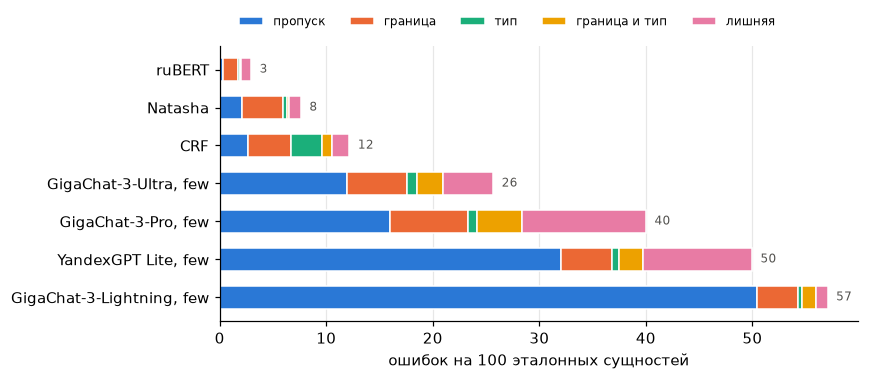

In [5]:
labels = {
    "missed": "пропуск",
    "wrong_boundary": "граница",
    "wrong_type": "тип",
    "wrong_boundary_and_type": "граница и тип",
    "spurious": "лишняя",
}
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]

fig, ax = plt.subplots(figsize=(8, 3.6))
data = per_100.iloc[::-1]
left = np.zeros(len(data))
for kind, color in zip(labels, colors, strict=True):
    ax.barh(
        data.index,
        data[kind],
        left=left,
        color=color,
        edgecolor="white",
        linewidth=1,
        height=0.6,
        label=labels[kind],
    )
    left += data[kind].to_numpy()
for y, total in enumerate(left):
    ax.text(total + 0.8, y, f"{total:.0f}", va="center", fontsize=8, color="#52514e")
ax.set_xlabel("ошибок на 100 эталонных сущностей")
ax.grid(axis="x", alpha=0.3)
ax.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.45, 1.15), fontsize=8)
plt.tight_layout()

## 3. Знакомые и новые сущности

Знакомая сущность: точно такая же строка была сущностью в train. Разрыв между знакомыми и новыми
сущностями складывается из двух причин: запоминания и того, что частые сущности («Россия», «Москва») проще
сами по себе. LLM train не видели, но у Ultra, Pro и YandexGPT знакомые сущности тоже лучше на 4-10 пунктов,
это и есть «естественная» часть разрыва. У CRF разрыв 14 пунктов, больше, чем у любой LLM, так что
запоминание у него заметно сверх этого. У GigaChat-3-Lightning картина обратная: частые сущности вроде «РФ»
он почти не находит.

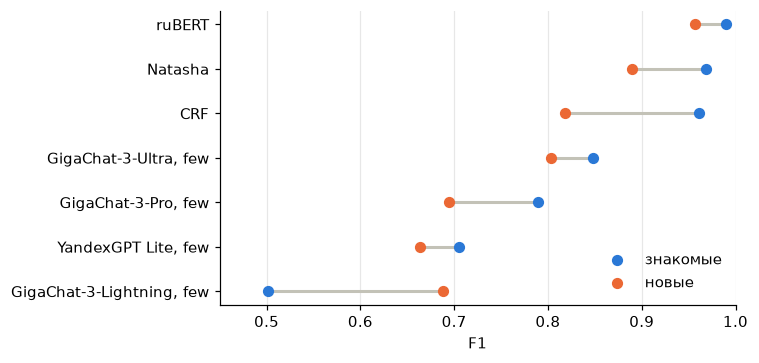

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.4))
order = MAIN[::-1]
for y, m in enumerate(order):
    su = evaluation[m]["c3_test"]["seen_unseen"]
    seen, unseen = su["seen"]["f1"], su["unseen"]["f1"]
    ax.plot([seen, unseen], [y, y], color="#c3c2b7", linewidth=2, zorder=1)
    ax.scatter(seen, y, color="#2a78d6", s=40, zorder=2, label="знакомые" if y == 0 else None)
    ax.scatter(unseen, y, color="#eb6834", s=40, zorder=2, label="новые" if y == 0 else None)
ax.set_yticks(range(len(order)), [NAMES[m] for m in order])
ax.set_xlabel("F1")
ax.set_xlim(0.45, 1.0)
ax.grid(axis="x", alpha=0.3)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()

## 4. Кавычки на краях сущностей

В эталоне Collection3 кавычки то входят в название (`" Данас "`), то нет. Ниже F1, если игнорировать кавычки
и скобки на краях сущностей и в эталоне, и в предсказаниях.

In [7]:
rows = []
for m in MAIN:
    strict = f1_from_sums(sentence_counts(y_true, preds[m]).sum(0))
    lenient = f1_from_sums(sentence_counts(y_true, preds[m], sentences).sum(0))
    rows.append(
        {
            "model": NAMES[m],
            "F1": strict,
            "F1 without edge quotes": lenient,
            "gain, points": 100 * (lenient - strict),
        }
    )
pd.DataFrame(rows).set_index("model").round(3)

,F1,F1 without edge quotes,"gain, points"
model,,,
ruBERT,0.9758586361373818,0.9804604853764779,0.460
Natasha,0.9346331708536433,0.9403824521934758,0.575
CRF,0.9011071967790639,0.9094111726220433,0.830
"GigaChat-3-Ultra, few",0.8275771847200418,0.8307169021454736,0.314
"GigaChat-3-Pro, few",0.7429979253112033,0.7515560165975104,0.856
"YandexGPT Lite, few",0.6855113636363637,0.6877840909090909,0.227
"GigaChat-3-Lightning, few",0.588903743315508,0.5905748663101604,0.167


## 5. Ошибки, общие для всех сильных моделей

ruBERT, Natasha, CRF и GigaChat-3-Ultra устроены совершенно по-разному. Если все четыре одинаково
расходятся с эталоном, вероятно, ошибка в эталоне.

In [8]:
strong_preds = {m: [set(tags_to_spans(p)) for p in preds[m]] for m in STRONG}


def context(tokens, s, e, width=6):
    left = " ".join(tokens[max(0, s - width) : s])
    right = " ".join(tokens[e : e + width])
    return f"{left} [[{' '.join(tokens[s:e])}]] {right}".strip()


found_by_all, missed_by_all = [], []
for i, tokens in enumerate(sentences):
    common = set.intersection(*(strong_preds[m][i] for m in STRONG))
    for s, e, t in sorted(common - gold_spans[i]):
        here = [(" ".join(tokens[a:b]), tt) for a, b, tt in gold_spans[i] if a < e and s < b]
        found_by_all.append({"context": context(tokens, s, e), "predicted": t, "gold here": here})
    for g in sorted(gold_spans[i]):
        if all(g not in strong_preds[m][i] for m in STRONG):
            missed_by_all.append({"sent": i, "span": g})

print(f"найдены всеми, но нет в эталоне: {len(found_by_all)}")
print(f"эталонные сущности, которые никто не нашёл точно: {len(missed_by_all)} из {n_gold}")
pd.DataFrame(found_by_all)

найдены всеми, но нет в эталоне: 15
эталонные сущности, которые никто не нашёл точно: 38 из 4001


,context,predicted,gold here
0,"Кандидаты и доктора наук [[РАН]] "" .",ORG,[]
1,""" [[Друзья Сирии]] "" договорились о срочной военной помощи",ORG,"[(Сирии, LOC)]"
2,"государственными делами , приводит издание "" [[Данас]] "" мнение своего источника .",ORG,"[("" Данас "", ORG)]"
3,"Как сообщает газета "" [[Данас]] "" , Вучич заявил в пятницу",ORG,"[("" Данас "", ORG)]"
4,- 2106 участкового в поселке Манас [[Карабудахкентского района]] Дагестана .,LOC,"[(Карабудахкентского района Дагестана, LOC)]"
5,участкового в поселке Манас Карабудахкентского района [[Дагестана]] .,LOC,"[(Карабудахкентского района Дагестана, LOC)]"
6,") и Эдуард Шуберт ( "" [[Справедливая Россия]] "" ) "" , — сообщает",ORG,"[("" Справедливая Россия "", ORG)]"
7,Янукович назначил губернаторов 14 областей [[Украины]],LOC,"[(Украины, ORG)]"
8,"Ашота Сукиасяна , в отношении которого [[Специальная следственная служба]] республики возбудила уголовное дело по обвинению",ORG,[]
9,[[Москва]] - Гавана - Каракас – в,LOC,"[(Москва - Гавана - Каракас, LOC)]"


Ручной разбор 15 случаев выше (по порядку строк):

| Категория | Строки | Сколько |
|---|---|---|
| Пропуск в эталоне, модели правы | 0, 8, 10, 12, 13, 14 | 6 |
| Неверная граница в эталоне (`РСН ,` с запятой) | 11 | 1 |
| Соглашение о кавычках | 2, 3, 6 | 3 |
| Спорное соглашение разметки | 1, 4, 5, 7, 9 | 5 |
| Явная ошибка моделей | | 0 |

Среди эталонных сущностей, которые не нашла точно ни одна сильная модель, часть тоже объясняется кавычками:

In [9]:
quote_related = sum(
    1 for r in missed_by_all if strip_edge_punct({r["span"]}, sentences[r["sent"]]) != {r["span"]}
)
print(
    f"из {len(missed_by_all)} случаев у {quote_related} эталонная сущность начинается "
    f"или заканчивается кавычкой или скобкой"
)
pd.DataFrame(
    [
        {"context": context(sentences[r["sent"]], *r["span"][:2]), "gold type": r["span"][2]}
        for r in missed_by_all[:12]
    ]
)

из 38 случаев у 9 эталонная сущность начинается или заканчивается кавычкой или скобкой


,context,gold type
0,""" Друзья [[Сирии]] "" договорились о срочной военной помощи",LOC
1,"в журнале Time Out Melbourne ( [[Roberto Seba]] ) , а ирландец Аллан Диксон",PER
2,"предстоящими строительными работами по созданию "" [[Музейного городка]] "" на Волхонке , считает специальный",LOC
3,"управления государственными делами , приводит издание [["" Данас ""]] мнение своего источника .",ORG
4,"- министр Ивица Дачич , и [["" Объединенные регионы Сербии ""]] во главе с министром финансов Младжаном",ORG
5,"Как сообщает газета [["" Данас ""]] , Вучич заявил в пятницу на",ORG
6,"Глава некоммерческого партнерства ( [[НП]] ) "" Совет Рынка "" Дмитрий",ORG
7,должностей были освобождены генеральный директор филиала [[ФСК]] ЕЭС - Магистральные электрические сети Урала,ORG
8,были освобождены генеральный директор филиала ФСК [[ЕЭС]] - Магистральные электрические сети Урала -,ORG
9,"Никитин , первый заместитель председателя правления [[ФСК]] ЕЭС Александр Бобров и зампред правления",ORG


## 6. LLM

### Zero-shot и few-shot

In [10]:
rows = []
for name, s in sorted(llm.items()):
    al, tok, n = s["alignment"], s["tokens"], s["n_sentences"]
    rows.append(
        {
            "model": NAMES[name],
            "F1": s["overall"]["f1"],
            "recall": s["overall"]["recall"],
            "F1 answered": s["answered_only"]["overall"]["f1"],
            "refused": al.get("no_json", 0),
            "other word form, %": 100
            * al.get("fuzzy", 0)
            / (al.get("exact", 0) + al.get("fuzzy", 0)),
            "not in text, %": 100 * al.get("unmatched", 0) / al.get("returned", 1),
            "tokens in": tok["input"] / n,
            "tokens cached": tok["cached_input"] / n,
            "tokens out": tok["output"] / n,
        }
    )
pd.DataFrame(rows).set_index("model").round(2)

,F1,recall,F1 answered,refused,"other word form, %","not in text, %",tokens in,tokens cached,tokens out
model,,,,,,,,,
"GigaChat-3-Lightning, few",0.59,0.44,0.59,6,9.63,0.85,37.27,586.66,21.80
"GigaChat-3-Lightning, zero",0.36,0.22,0.36,6,23.96,0.71,41.85,204.25,13.95
"GigaChat-3-Pro, few",0.74,0.72,0.75,6,4.42,1.07,38.16,585.76,35.55
"GigaChat-3-Pro, zero",0.68,0.58,0.68,6,19.99,1.29,41.85,204.25,28.15
"GigaChat-3-Ultra, few",0.83,0.79,0.84,6,3.98,0.44,52.32,571.60,34.27
"YandexGPT Lite, few",0.69,0.60,0.82,501,4.54,5.21,454.24,0.00,40.88
"YandexGPT Lite, zero",0.68,0.59,0.79,443,35.12,6.46,190.24,0.00,52.54


- `refused`: ответов без JSON. У YandexGPT это отказы модерации «Я не могу обсуждать эту тему»
  на политических новостях.
- `other word form`: доля сущностей, найденных только нечётким сопоставлением, то есть LLM изменила
  словоформу («Москва» вместо «Москве»).
- `tokens cached`: GigaChat кеширует одинаковое начало промпта и считает эти токены отдельно.

### F1 по типам сущностей

In [11]:
per_type = pd.DataFrame(
    {NAMES[m]: {t: ner_report(y_true, preds[m])[t]["f1"] for t in ENTITY_TYPES} for m in MAIN}
).T
per_type.round(3)

,PER,LOC,ORG
ruBERT,0.998,0.981,0.943
Natasha,0.947,0.947,0.908
CRF,0.940,0.917,0.836
"GigaChat-3-Ultra, few",0.953,0.814,0.672
"GigaChat-3-Pro, few",0.896,0.708,0.568
"YandexGPT Lite, few",0.773,0.660,0.602
"GigaChat-3-Lightning, few",0.864,0.281,0.365


### Примеры ошибок GigaChat-3-Ultra (рядом ответ ruBERT)

In [12]:
_, ultra_errors = classify_errors(y_true, preds["gigachat3_ultra_few"])
rubert_spans = strong_preds["rubert"]
rng = np.random.default_rng(0)


def describe(spans, tokens):
    return ", ".join(f"[{' '.join(tokens[s:e])}]{t}" for s, e, t in spans) or "-"


rows = []
for kind in ["wrong_boundary", "missed", "spurious"]:
    pool = [e for e in ultra_errors if e["kind"] == kind]
    for k in rng.choice(len(pool), 4, replace=False):
        e = pool[int(k)]
        tokens = sentences[e["sent"]]
        span = e["gold"] or e["pred"][0]
        nearby = [q for q in rubert_spans[e["sent"]] if q[0] < span[1] and span[0] < q[1]]
        rows.append(
            {
                "kind": kind,
                "context": context(tokens, span[0], span[1]),
                "gold": describe([e["gold"]] if e["gold"] else [], tokens),
                "Ultra": describe(e["pred"], tokens),
                "ruBERT": describe(nearby, tokens),
            }
        )
pd.DataFrame(rows)

,kind,context,gold,Ultra,ruBERT
0,wrong_boundary,на следующий день - на заседании [[Общественной палаты]] столицы .,[Общественной палаты]ORG,[Общественной палаты столицы]ORG,[Общественной палаты]ORG
1,wrong_boundary,"По результатам проверки РЭК КО областной [[Контрольно - счётной палатой]] , инициированной главой региона , установлено",[Контрольно - счётной палатой]ORG,[областной Контрольно - счётной палатой]ORG,[Контрольно - счётной палатой]ORG
2,wrong_boundary,"кандидатуру премьер - министра Крыма с [[Верховным Советом]] автономной республики , после чего кандидат",[Верховным Советом]ORG,[Верховным Советом автономной республики]ORG,[Верховным Советом]ORG
3,wrong_boundary,Болгов стал заместителем начальника главного управления [[МВД]] РФ по Краснодарскому краю ; полковник,[МВД]ORG,[МВД РФ]ORG,[МВД]ORG
4,missed,", а также действующий заместитель руководителя [[ФСФР]] Александр Синенко .",[ФСФР]ORG,-,[ФСФР]ORG
5,missed,Официальный представитель [[СК]] РФ Владимир Маркин заявил во вторник,[СК]ORG,-,[СК]ORG
6,missed,"фракции "" Справедливая Россия "" в [[Госдуме]] , замглавы думского комитета по безопасности",[Госдуме]ORG,-,[Госдуме]ORG
7,missed,Сбербанка на должность зампреда и руководителя [[Главной инспекции кредитных организаций]] .,[Главной инспекции кредитных организаций]ORG,-,[Главной инспекции кредитных организаций]ORG
8,spurious,"контроле за деятельностью иностранных разведок ( [[FISA]] ) , который развязал силовикам руки",-,[FISA]ORG,[FISA]ORG
9,spurious,Ночной митинг на [[Партизанской поляне]] в День памяти и скорби проводится,-,[Партизанской поляне]LOC,[Партизанской поляне]LOC


## 7. Перенос на WikiNEuRal

Локальные модели, обученные на Collection3 (новости), на тесте WikiNEuRal-ru (Википедия). Разметка
WikiNEuRal автоматическая, а класс MISC мы превратили в O. Если модель отметила такую MISC-сущность
как ORG или LOC, это засчитывается как лишняя сущность, хотя что-то там действительно есть.

In [13]:
wn = load_wikineural_ru("test")
wn_sentences, wn_true = list(wn["tokens"]), tag_names(wn)
misc = wikineural_misc_spans("test")

rows = []
for m in ["rubert", "natasha", "crf"]:
    pred = load_predictions(m, "wikineural_test", [len(s) for s in wn_sentences])
    counts, errs = classify_errors(wn_true, pred)
    spurious = [e for e in errs if e["kind"] == "spurious"]
    on_misc = [
        e
        for e in spurious
        if any(a < e["pred"][0][1] and e["pred"][0][0] < b for a, b in misc[e["sent"]])
    ]
    # the same F1, but predictions lying on a MISC entity are not counted as errors
    tp = n_pred = n_true = 0
    for k, (t, p) in enumerate(zip(wn_true, pred, strict=True)):
        g, q = set(tags_to_spans(t)), set(tags_to_spans(p))
        q = {s for s in q if s in g or not any(a < s[1] and s[0] < b for a, b in misc[k])}
        tp, n_pred, n_true = tp + len(g & q), n_pred + len(q), n_true + len(g)
    rows.append(
        {
            "model": NAMES[m],
            "F1": evaluation[m]["wikineural_test"]["f1"],
            "spurious": len(spurious),
            "spurious on MISC, %": 100 * len(on_misc) / len(spurious),
            "F1 without MISC overlaps": float(f1_from_sums([tp, n_pred, n_true])),
            "wrong type": counts["wrong_type"],
            "missed": counts["missed"],
        }
    )
pd.DataFrame(rows).set_index("model").round(3)

,F1,spurious,"spurious on MISC, %",F1 without MISC overlaps,wrong type,missed
model,,,,,,
ruBERT,0.799,1268,45.820,0.815,981,760
Natasha,0.764,1463,50.991,0.783,1336,937
CRF,0.563,2739,63.600,0.597,2819,1775


## Выводы

- **ruBERT лучше всех** по F1 (0.976), по ошибкам каждого вида и по качеству на новых сущностях (0.957).
  Квантизованная версия для CPU не хуже исходной.
- **Почти половина ошибок ruBERT связана с границами** (57 из 118). Часть из них объясняется
  непоследовательной разметкой кавычек и спорными соглашениями корпуса, а не ошибками модели.
  При этом без учёта кавычек на краях F1 растёт всего на 0.5 пункта, так что основная часть ошибок границ
  связана не с кавычками.
- **Шум эталона ограничивает достижимый F1.** В 15 случаях, где все четыре сильные модели согласны между собой
  и расходятся с эталоном, нет ни одной явной ошибки моделей: 6 пропусков в разметке, 1 неверная граница,
  3 расхождения по кавычкам, 5 спорных соглашений.
- **CRF сильнее всех опирается на запоминание**: разница между знакомыми и новыми сущностями у него 14 пунктов,
  у ruBERT 3, у LLM, которые train не видели, 4-10. На WikiNEuRal, где новых сущностей большинство,
  F1 CRF падает до 0.56.
- **Главная проблема LLM — пропуски**: recall от 0.22 до 0.79 при precision 0.77-0.91. Лучшая модель
  (GigaChat-3-Ultra с примерами) отстаёт от ruBERT на 15 пунктов F1, особенно на организациях (0.67 против 0.94).
  Few-shot помогает всем моделям и почти убирает изменение словоформ.
- **YandexGPT отказывается обрабатывать около четверти новостей** из-за модерации,
  поэтому на таких текстах его нельзя использовать даже при хорошем качестве ответов.
- **На WikiNEuRal precision занижен нашей переразметкой**: от 46% до 64% «лишних» сущностей приходятся
  на исходные MISC-сущности.